# Factores de Conversión Acumulados — Análisis de Madurez

Este notebook analiza la relación entre la mora inicial (MOB 1) y la mora en cada MOB posterior.

**Factor de conversión**: `índice(MOB_n) / índice(MOB_1)`

- Factor > 1: la mora al MOB n es **mayor** que al nacer (deterioro neto)
- Factor = 1: la mora se mantuvo igual
- Factor < 1: la mora al MOB n es **menor** que al nacer (curación neta)

---
## 0. Setup

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

# ---------------------------------------------------------------------------
# PARÁMETROS CONFIGURABLES
# ---------------------------------------------------------------------------
MOB_MADURO = 15                 # MOB objetivo de madurez
COLOR_2024 = "#2171b5"
COLOR_2025 = "#e6550d"
COLOR_2026 = "#2ca02c"
ALPHA_INDIVIDUAL = 0.20
ALPHA_HIGHLIGHT = 0.85

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: d:\Python\Vintage Saldo (moroso-vencido)


---
## 1. Generar factores de conversión

In [2]:
result = subprocess.run(
    ["py", os.path.join(SRC_DIR, "generar_factores_conversion.py")],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)

GeneraciÃ³n de Factores de ConversiÃ³n Acumulados
Matriz leÃ­da: 40 cohortes x 40 MOBs

Factores de conversiÃ³n guardados: d:\Python\Vintage Saldo (moroso-vencido)\data\processed\factores_conversion.csv
Resumen estadÃ­stico guardado: d:\Python\Vintage Saldo (moroso-vencido)\data\processed\factores_conversion_resumen.csv

  MOB |   N | Promedio |  Mediana |  DesvÃ­o |     MÃ­n |     MÃ¡x |  Tendencia
---------------------------------------------------------------------------
    1 |  40 |    1.000 |    1.000 |   0.000 |   1.000 |   1.000 |    ESTABLE
    2 |  39 |    1.007 |    1.035 |   0.105 |   0.809 |   1.188 |   SUBIENDO
    3 |  38 |    1.040 |    1.051 |   0.145 |   0.765 |   1.340 |   SUBIENDO
    4 |  37 |    1.105 |    1.129 |   0.180 |   0.770 |   1.495 |   SUBIENDO
    5 |  36 |    1.158 |    1.153 |   0.219 |   0.819 |   1.619 |   SUBIENDO
    6 |  35 |    1.241 |    1.257 |   0.244 |   0.826 |   1.886 |   SUBIENDO
    7 |  34 |    1.353 |    1.247 |   0.313 |   0.830 |   2

In [3]:
# Leer datos
matriz = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_vintage.csv"), sep=";", decimal=",", index_col=0)
factores_conv = pd.read_csv(os.path.join(PROCESSED_DIR, "factores_conversion.csv"), sep=";", decimal=",", index_col=0)
resumen = pd.read_csv(os.path.join(PROCESSED_DIR, "factores_conversion_resumen.csv"), sep=";", decimal=",")

print(f"Cohortes: {len(factores_conv)} | MOBs: {len(factores_conv.columns)}")
factores_conv.style.format("{:.3f}", na_rep="-").background_gradient(cmap="RdYlGn_r", vmin=0.6, vmax=1.8, axis=None)

Cohortes: 40 | MOBs: 40


,MOB_1,MOB_2,MOB_3,MOB_4,MOB_5,MOB_6,MOB_7,MOB_8,MOB_9,MOB_10,MOB_11,MOB_12,MOB_13,MOB_14,MOB_15,MOB_16,MOB_17,MOB_18,MOB_19,MOB_20,MOB_21,MOB_22,MOB_23,MOB_24,MOB_25,MOB_26,MOB_27,MOB_28,MOB_29,MOB_30,MOB_31,MOB_32,MOB_33,MOB_34,MOB_35,MOB_36,MOB_37,MOB_38,MOB_39,MOB_40
cohorte,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-10,1.000,0.835,0.837,0.957,0.968,1.036,1.031,1.171,1.094,1.057,1.011,0.985,0.931,0.876,0.849,0.827,0.797,0.777,0.753,0.732,0.711,0.698,0.685,0.675,0.664,0.650,0.641,0.638,0.633,0.629,0.623,0.618,0.613,0.609,0.607,0.604,0.601,0.597,0.596,0.594
2022-11,1.000,0.953,1.056,1.055,1.091,1.115,1.326,1.224,1.187,1.131,1.112,1.055,0.981,0.953,0.924,0.886,0.861,0.832,0.800,0.773,0.756,0.743,0.729,0.724,0.708,0.699,0.694,0.690,0.686,0.682,0.676,0.671,0.667,0.663,0.659,0.656,0.653,0.649,0.646,-
2022-12,1.000,1.114,1.007,1.039,1.070,1.257,1.173,1.181,1.124,1.100,1.045,0.979,0.942,0.907,0.869,0.846,0.818,0.789,0.763,0.747,0.736,0.726,0.718,0.706,0.696,0.688,0.682,0.677,0.674,0.669,0.664,0.660,0.658,0.655,0.653,0.649,0.646,0.645,-,-
2023-01,1.000,0.869,0.850,0.890,0.875,0.826,1.045,0.988,0.990,0.945,0.872,0.839,0.814,0.773,0.751,0.714,0.682,0.647,0.629,0.613,0.601,0.589,0.577,0.570,0.564,0.553,0.546,0.542,0.536,0.532,0.528,0.524,0.521,0.518,0.515,0.513,0.511,-,-,-
2023-02,1.000,0.969,0.994,0.977,0.950,1.072,1.075,1.252,1.199,1.118,1.077,1.051,0.999,0.966,0.924,0.875,0.837,0.814,0.796,0.774,0.762,0.747,0.737,0.731,0.718,0.712,0.707,0.702,0.697,0.691,0.686,0.681,0.677,0.672,0.670,0.667,-,-,-,-
2023-03,1.000,0.984,0.923,0.879,0.942,0.993,1.232,1.194,1.115,1.069,1.045,0.998,0.961,0.913,0.858,0.817,0.787,0.771,0.746,0.731,0.718,0.708,0.704,0.699,0.688,0.678,0.672,0.668,0.663,0.660,0.656,0.653,0.647,0.644,0.641,-,-,-,-,-
2023-04,1.000,0.896,0.765,0.853,0.912,1.078,1.139,1.066,1.028,1.012,0.962,0.930,0.875,0.823,0.776,0.753,0.731,0.712,0.699,0.682,0.672,0.669,0.663,0.661,0.654,0.643,0.634,0.631,0.630,0.628,0.626,0.621,0.619,0.617,-,-,-,-,-,-
2023-05,1.000,0.842,0.947,1.031,1.061,1.271,1.217,1.230,1.213,1.157,1.118,1.046,0.984,0.929,0.895,0.874,0.850,0.838,0.820,0.809,0.803,0.797,0.792,0.790,0.780,0.770,0.767,0.764,0.759,0.758,0.754,0.751,0.749,-,-,-,-,-,-,-
2023-06,1.000,1.115,1.213,1.211,1.241,1.213,1.465,1.461,1.387,1.347,1.281,1.209,1.138,1.093,1.062,1.032,1.008,0.985,0.970,0.960,0.950,0.942,0.939,0.932,0.923,0.916,0.913,0.906,0.902,0.895,0.891,0.888,-,-,-,-,-,-,-,-


---
## 2. Curvas de factor de conversión por cohorte

Cada línea muestra cómo evoluciona el ratio `índice(MOB_n) / índice(MOB_1)` para una cohorte.
La línea punteada roja en **1.0** marca el punto neutro.

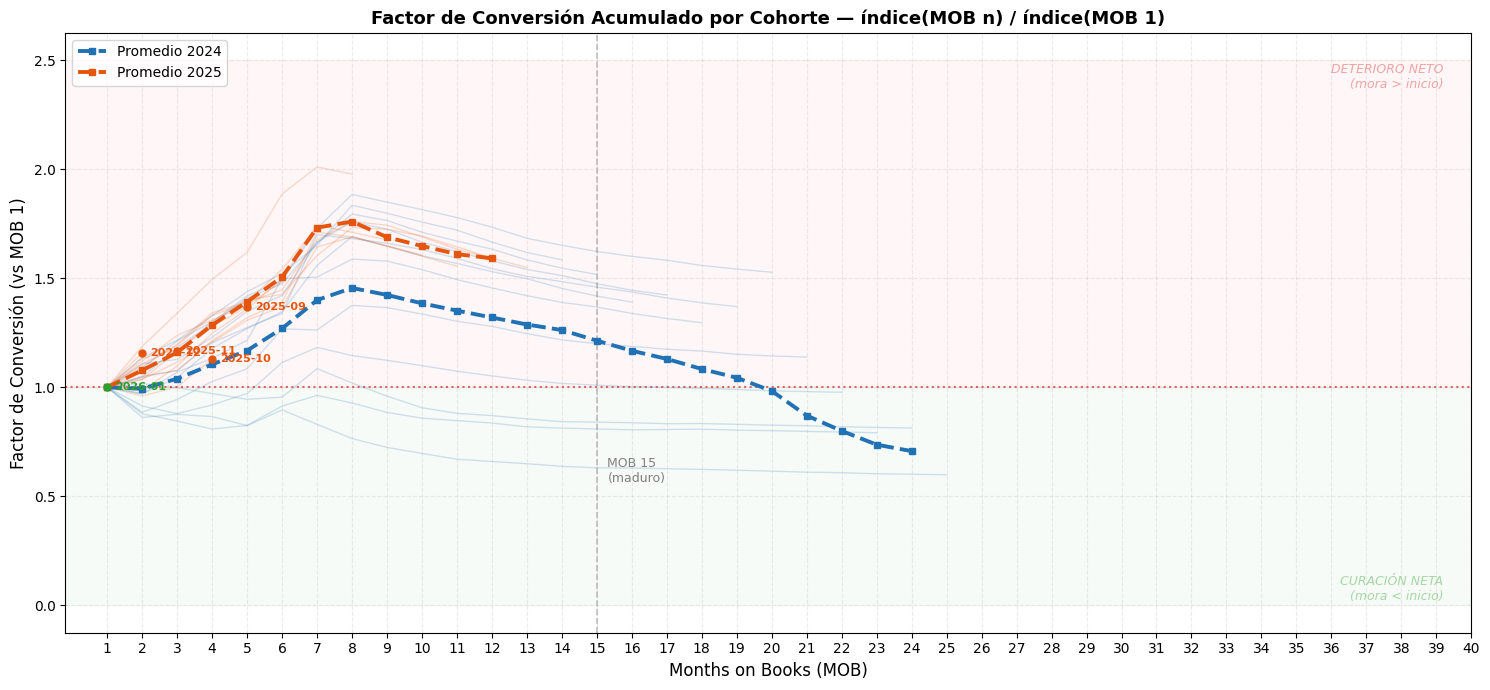

Gráfico guardado en reports/factores_conversion.png


In [4]:
cohortes_ordenadas = sorted(factores_conv.index)
cohortes_2024 = [c for c in cohortes_ordenadas if c.startswith("2024")]
cohortes_2025 = [c for c in cohortes_ordenadas if c.startswith("2025")]
cohortes_2026 = [c for c in cohortes_ordenadas if c.startswith("2026")]

def extraer_fc(cohorte):
    vals = factores_conv.loc[cohorte].dropna()
    mobs = [int(c.replace("MOB_", "")) for c in vals.index]
    return mobs, vals.values

fig, ax = plt.subplots(figsize=(15, 7))

ax.axhline(y=1.0, color="#d62728", linewidth=1.5, linestyle=":", alpha=0.7, zorder=0)
ax.axhspan(1.0, 2.5, alpha=0.03, color="red", zorder=0)
ax.axhspan(0.0, 1.0, alpha=0.03, color="green", zorder=0)

if MOB_MADURO:
    ax.axvline(x=MOB_MADURO, color="gray", linewidth=1.2, linestyle="--", alpha=0.5, zorder=0)
    ax.text(MOB_MADURO + 0.3, 0.55, f"MOB {MOB_MADURO}\n(maduro)",
            fontsize=9, color="gray", va="bottom")

for cohorte in cohortes_2024:
    mobs, vals = extraer_fc(cohorte)
    ax.plot(mobs, vals, color=COLOR_2024, alpha=ALPHA_INDIVIDUAL, linewidth=1.0, zorder=1)

for cohorte in cohortes_2025:
    mobs, vals = extraer_fc(cohorte)
    ax.plot(mobs, vals, color=COLOR_2025, alpha=ALPHA_INDIVIDUAL, linewidth=1.0, zorder=1)

for cohorte in cohortes_2026:
    mobs, vals = extraer_fc(cohorte)
    ax.plot(mobs, vals, color=COLOR_2026, alpha=ALPHA_INDIVIDUAL, linewidth=1.0, zorder=1)

# Promedio por año
def promedio_fc(cohortes):
    mobs_out, vals_out = [], []
    for col in factores_conv.columns:
        vals = factores_conv.loc[cohortes, col].dropna()
        if len(vals) >= 2:
            mobs_out.append(int(col.replace("MOB_", "")))
            vals_out.append(vals.mean())
    return mobs_out, vals_out

pm24, pv24 = promedio_fc(cohortes_2024)
pm25, pv25 = promedio_fc(cohortes_2025) if len(cohortes_2025) >= 2 else ([], [])

if pm24:
    ax.plot(pm24, pv24, color=COLOR_2024, linewidth=2.8, linestyle="--",
            marker="s", markersize=5, zorder=4, label="Promedio 2024")
if pm25:
    ax.plot(pm25, pv25, color=COLOR_2025, linewidth=2.8, linestyle="--",
            marker="s", markersize=5, zorder=4, label="Promedio 2025")

# Anotar últimas cohortes
for cohorte in cohortes_ordenadas[-5:]:
    mobs, vals = extraer_fc(cohorte)
    color = COLOR_2024 if cohorte.startswith("2024") else (COLOR_2025 if cohorte.startswith("2025") else COLOR_2026)
    ax.annotate(cohorte, xy=(mobs[-1], vals[-1]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=8, fontweight="bold", color=color, va="center", zorder=5)
    ax.plot(mobs[-1], vals[-1], "o", color=color, markersize=5, zorder=5)

ax.set_xlabel("Months on Books (MOB)", fontsize=12)
ax.set_ylabel("Factor de Conversión (vs MOB 1)", fontsize=12)
ax.set_title("Factor de Conversión Acumulado por Cohorte — índice(MOB n) / índice(MOB 1)",
             fontsize=13, fontweight="bold")
ax.set_xticks(range(1, len(factores_conv.columns) + 1))
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(fontsize=10, loc="upper left")

ax.text(0.98, 0.95, "DETERIORO NETO\n(mora > inicio)", transform=ax.transAxes,
        fontsize=9, ha="right", va="top", color="#d62728", alpha=0.4, fontstyle="italic")
ax.text(0.98, 0.05, "CURACIÓN NETA\n(mora < inicio)", transform=ax.transAxes,
        fontsize=9, ha="right", va="bottom", color="#2ca02c", alpha=0.4, fontstyle="italic")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "factores_conversion.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/factores_conversion.png")

---
## 3. Factor de conversión al MOB maduro

Compara el factor `índice(MOB_maduro) / índice(MOB_1)` entre cohortes para ver si hay tendencia.

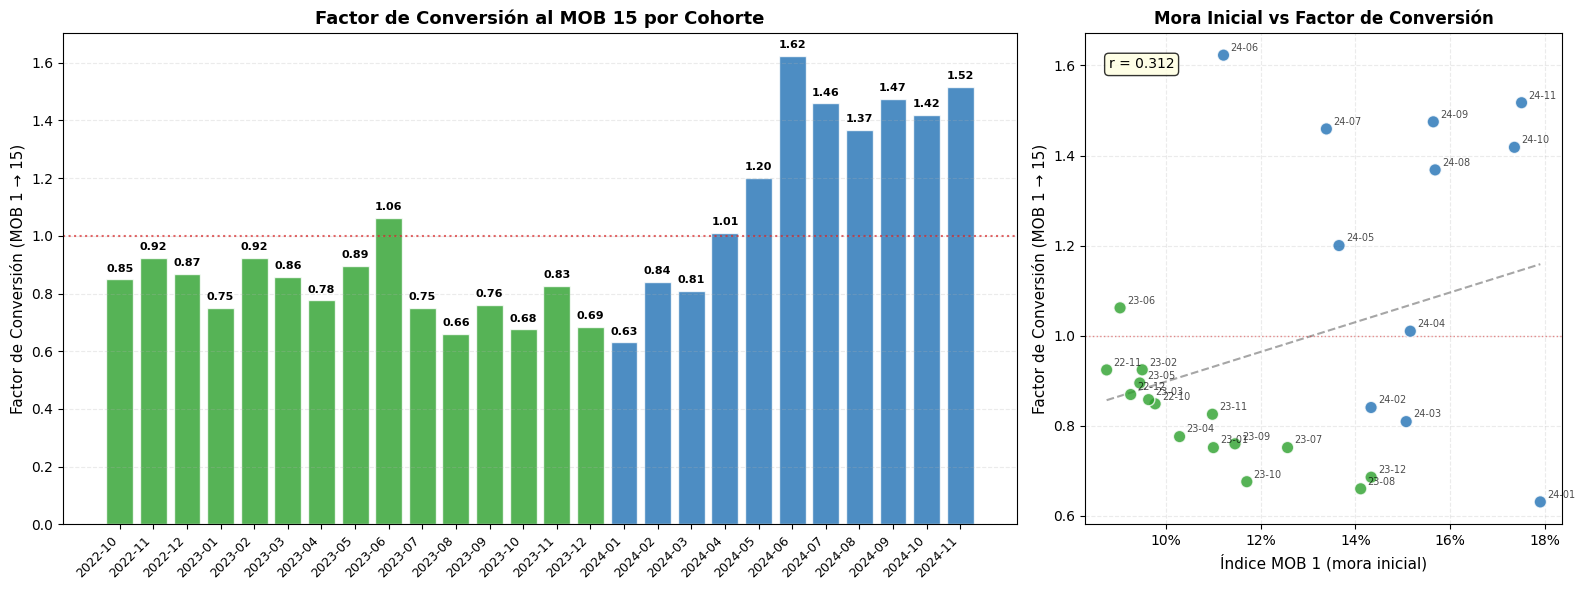

In [5]:
mob_col = f"MOB_{MOB_MADURO}"
cohortes_con_dato = factores_conv[mob_col].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [2, 1]})

# --- Panel izquierdo: barras por cohorte ---
colores = []
for c in cohortes_con_dato.index:
    if c.startswith("2024"):
        colores.append(COLOR_2024)
    elif c.startswith("2025"):
        colores.append(COLOR_2025)
    else:
        colores.append(COLOR_2026)

bars = ax1.bar(range(len(cohortes_con_dato)), cohortes_con_dato.values, color=colores, alpha=0.8, edgecolor="white")
ax1.axhline(y=1.0, color="#d62728", linewidth=1.5, linestyle=":", alpha=0.7)
ax1.set_xticks(range(len(cohortes_con_dato)))
ax1.set_xticklabels(cohortes_con_dato.index, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel(f"Factor de Conversión (MOB 1 → {MOB_MADURO})", fontsize=11)
ax1.set_title(f"Factor de Conversión al MOB {MOB_MADURO} por Cohorte", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.25, linestyle="--", axis="y")

for i, (cohorte, val) in enumerate(cohortes_con_dato.items()):
    ax1.text(i, val + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# --- Panel derecho: scatter MOB_1 vs Factor ---
mob1_vals = matriz.loc[cohortes_con_dato.index, "MOB_1"]
scatter_colors = [COLOR_2024 if c.startswith("2024") else (COLOR_2025 if c.startswith("2025") else COLOR_2026) for c in cohortes_con_dato.index]

ax2.scatter(mob1_vals, cohortes_con_dato.values, c=scatter_colors, s=80, alpha=0.8, edgecolors="white", zorder=3)

# Línea de tendencia
z = np.polyfit(mob1_vals, cohortes_con_dato.values, 1)
p = np.poly1d(z)
x_line = np.linspace(mob1_vals.min(), mob1_vals.max(), 50)
ax2.plot(x_line, p(x_line), "--", color="gray", linewidth=1.5, alpha=0.7, zorder=2)

for cohorte in cohortes_con_dato.index:
    ax2.annotate(cohorte[-5:], xy=(mob1_vals[cohorte], cohortes_con_dato[cohorte]),
                 xytext=(5, 3), textcoords="offset points", fontsize=7, alpha=0.7)

ax2.axhline(y=1.0, color="#d62728", linewidth=1, linestyle=":", alpha=0.5)
ax2.set_xlabel("Índice MOB 1 (mora inicial)", fontsize=11)
ax2.set_ylabel(f"Factor de Conversión (MOB 1 → {MOB_MADURO})", fontsize=11)
ax2.set_title("Mora Inicial vs Factor de Conversión", fontsize=12, fontweight="bold")
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.grid(True, alpha=0.25, linestyle="--")

# Correlación
corr = np.corrcoef(mob1_vals, cohortes_con_dato.values)[0, 1]
ax2.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax2.transAxes, fontsize=10, va="top",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "factor_conversion_maduro.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Evolución temporal del factor de conversión por MOB intermedio

Muestra cómo cambia el factor acumulado a distintos MOBs a lo largo de las cohortes.
Si las líneas suben, el deterioro relativo está aumentando con el tiempo.

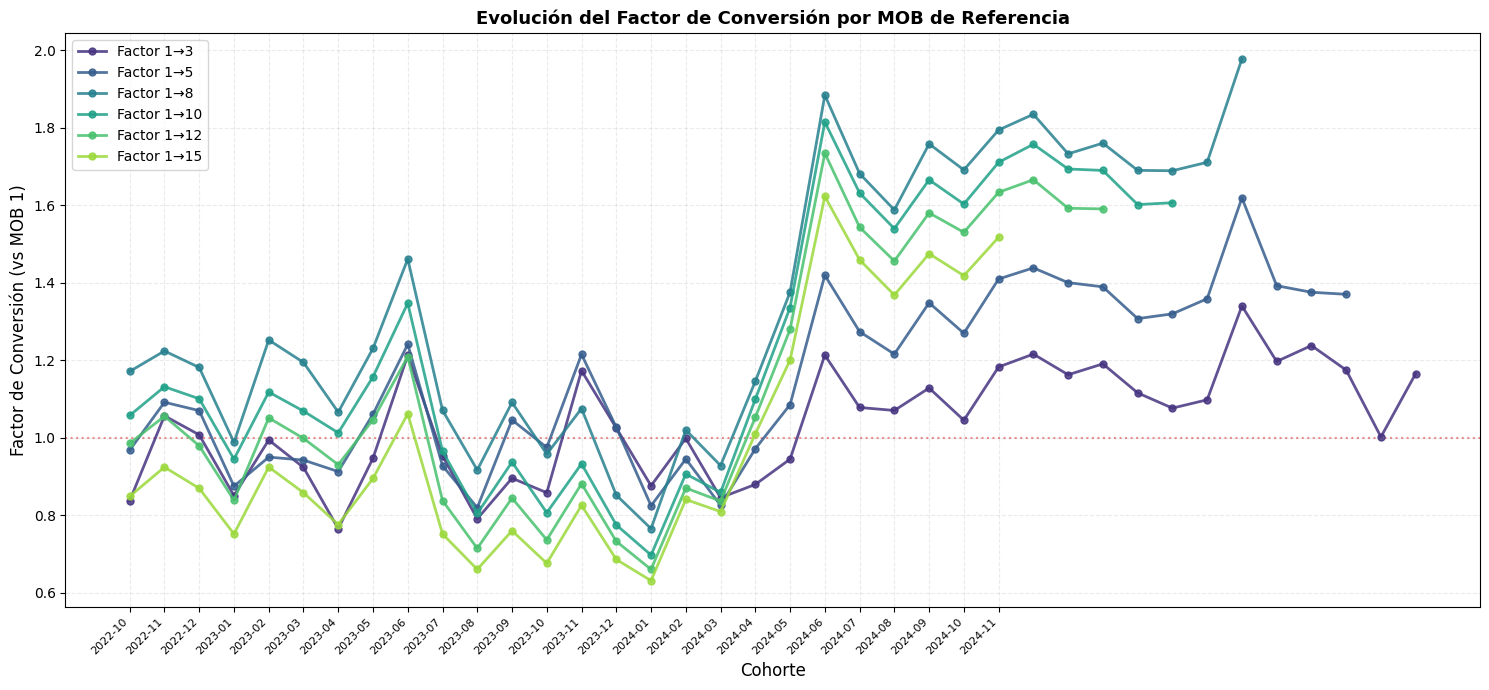

In [6]:
mobs_referencia = [3, 5, 8, 10, 12, MOB_MADURO]
colores_mob = plt.cm.viridis(np.linspace(0.15, 0.85, len(mobs_referencia)))

fig, ax = plt.subplots(figsize=(15, 7))

ax.axhline(y=1.0, color="#d62728", linewidth=1.5, linestyle=":", alpha=0.5)

for mob_ref, color in zip(mobs_referencia, colores_mob):
    col = f"MOB_{mob_ref}"
    if col not in factores_conv.columns:
        continue
    vals = factores_conv[col].dropna()
    if len(vals) < 2:
        continue
    ax.plot(range(len(vals)), vals.values, marker="o", markersize=5,
            linewidth=2, color=color, label=f"Factor 1→{mob_ref}", alpha=0.85)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=45, ha="right", fontsize=8)

ax.set_xlabel("Cohorte", fontsize=12)
ax.set_ylabel("Factor de Conversión (vs MOB 1)", fontsize=12)
ax.set_title("Evolución del Factor de Conversión por MOB de Referencia", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.25, linestyle="--")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "evolucion_factor_conversion.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Heatmap: Factor de conversión (cohorte × MOB)

Vista matricial con gradiente de color. Rojo = deterioro alto, verde = curación.

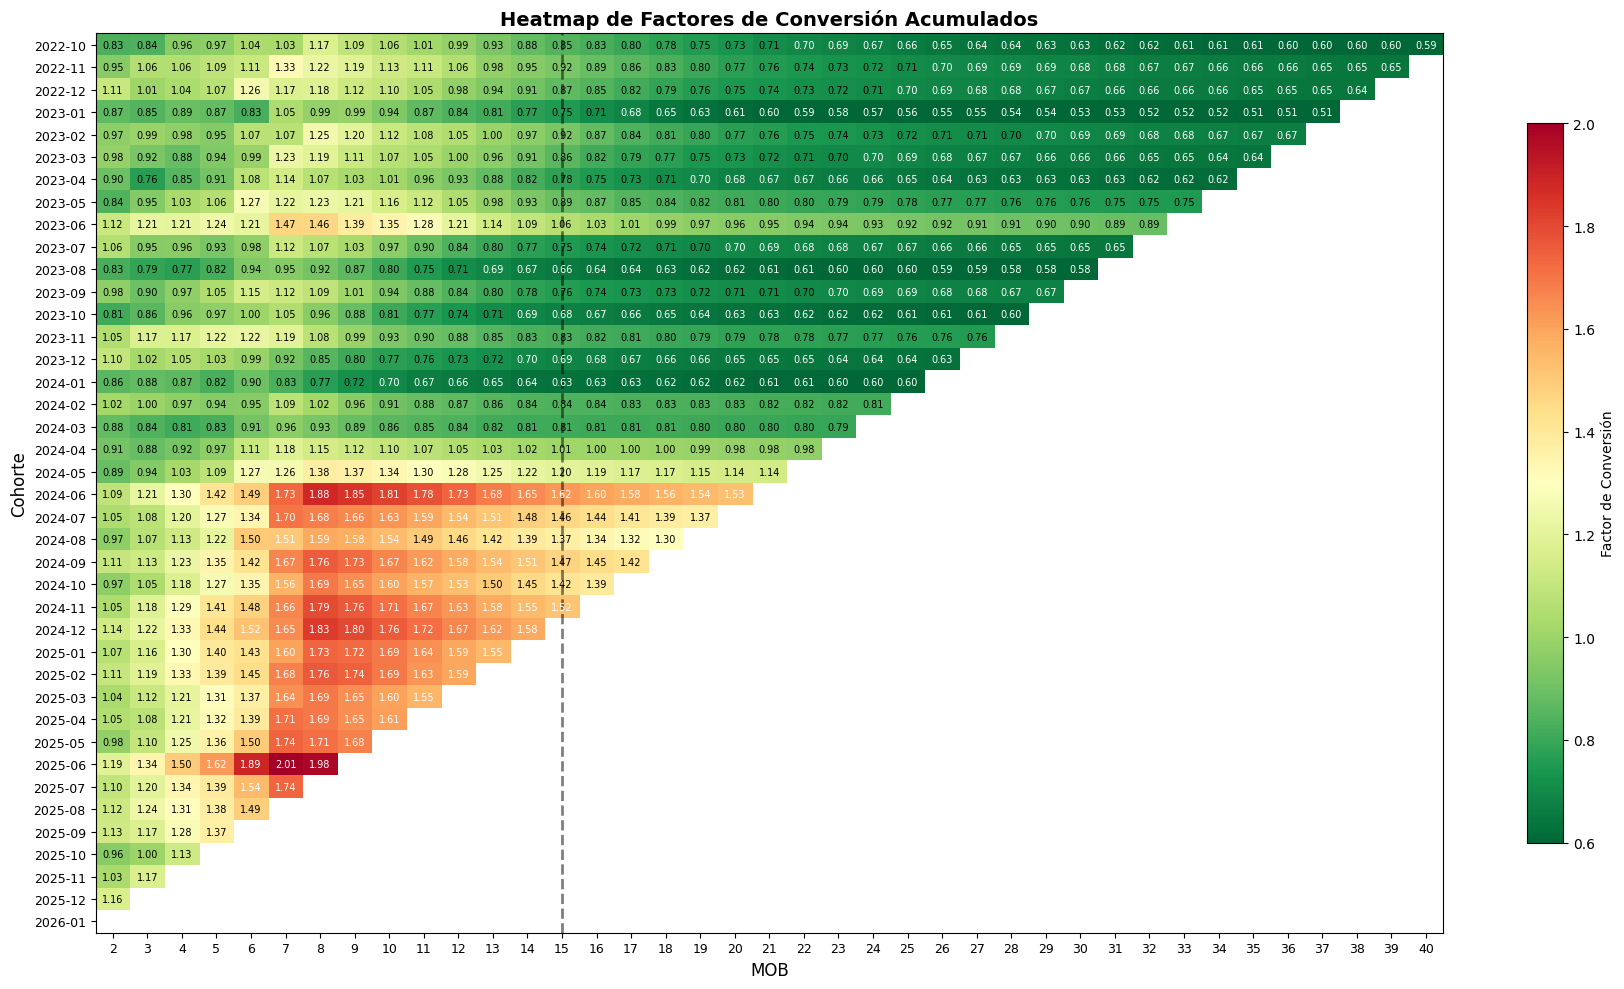

In [7]:
fig, ax = plt.subplots(figsize=(18, 10))

# Preparar datos para heatmap (sin MOB_1 que siempre es 1.0)
cols_hm = [c for c in factores_conv.columns if c != "MOB_1"]
data_hm = factores_conv[cols_hm].copy()

im = ax.imshow(data_hm.values, cmap="RdYlGn_r", aspect="auto", vmin=0.6, vmax=2.0)

ax.set_xticks(range(len(cols_hm)))
ax.set_xticklabels([c.replace("MOB_", "") for c in cols_hm], fontsize=9)
ax.set_yticks(range(len(data_hm.index)))
ax.set_yticklabels(data_hm.index, fontsize=9)

# Anotar valores
for i in range(len(data_hm.index)):
    for j in range(len(cols_hm)):
        val = data_hm.iloc[i, j]
        if pd.notna(val):
            color_text = "white" if val > 1.5 or val < 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color_text)

ax.set_xlabel("MOB", fontsize=12)
ax.set_ylabel("Cohorte", fontsize=12)
ax.set_title("Heatmap de Factores de Conversión Acumulados", fontsize=14, fontweight="bold")

# MOB maduro
if MOB_MADURO > 1:
    mob_idx = cols_hm.index(f"MOB_{MOB_MADURO}") if f"MOB_{MOB_MADURO}" in cols_hm else None
    if mob_idx is not None:
        ax.axvline(x=mob_idx, color="black", linewidth=2, linestyle="--", alpha=0.5)

plt.colorbar(im, ax=ax, label="Factor de Conversión", shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "heatmap_factores_conversion.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Resumen estadístico por MOB

In [8]:
print(f"{'MOB':>5s} | {'N':>3s} | {'Promedio':>8s} | {'Mediana':>8s} | {'Desvío':>7s} | {'Mín':>7s} | {'Máx':>7s} | {'1ra mitad':>9s} | {'2da mitad':>9s} | {'Cambio%':>7s} | {'Tendencia':>10s}")
print("-" * 110)
for _, row in resumen.iterrows():
    print(f"{int(row['mob']):>5d} | {int(row['n_cohortes']):>3d} | "
          f"{row['promedio']:>8.3f} | {row['mediana']:>8.3f} | "
          f"{row['desvio']:>7.3f} | {row['minimo']:>7.3f} | "
          f"{row['maximo']:>7.3f} | {row['prom_1ra_mitad']:>9.3f} | "
          f"{row['prom_2da_mitad']:>9.3f} | {row['cambio_pct']:>+6.1f}% | "
          f"{row['tendencia']:>10s}")

  MOB |   N | Promedio |  Mediana |  Desvío |     Mín |     Máx | 1ra mitad | 2da mitad | Cambio% |  Tendencia
--------------------------------------------------------------------------------------------------------------
    1 |  40 |    1.000 |    1.000 |   0.000 |   1.000 |   1.000 |     1.000 |     1.000 |   +0.0% |    ESTABLE
    2 |  39 |    1.007 |    1.035 |   0.105 |   0.809 |   1.188 |     0.951 |     1.059 |  +11.4% |   SUBIENDO
    3 |  38 |    1.040 |    1.051 |   0.145 |   0.765 |   1.340 |     0.941 |     1.139 |  +21.0% |   SUBIENDO
    4 |  37 |    1.105 |    1.129 |   0.180 |   0.770 |   1.495 |     0.968 |     1.235 |  +27.6% |   SUBIENDO
    5 |  36 |    1.158 |    1.153 |   0.219 |   0.819 |   1.619 |     0.984 |     1.331 |  +35.3% |   SUBIENDO
    6 |  35 |    1.241 |    1.257 |   0.244 |   0.826 |   1.886 |     1.058 |     1.413 |  +33.5% |   SUBIENDO
    7 |  34 |    1.353 |    1.247 |   0.313 |   0.830 |   2.010 |     1.117 |     1.589 |  +42.3% |   SUBIENDO
 

---
## 7. Análisis de dispersión del factor por MOB

Box plot que muestra la distribución del factor de conversión en cada MOB.
Si la dispersión crece con el MOB, significa que las cohortes divergen con el tiempo.

C:\Users\skannema\AppData\Local\Temp\ipykernel_14380\2871981220.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, patch_artist=True, labels=[str(m) for m in mobs_bp],


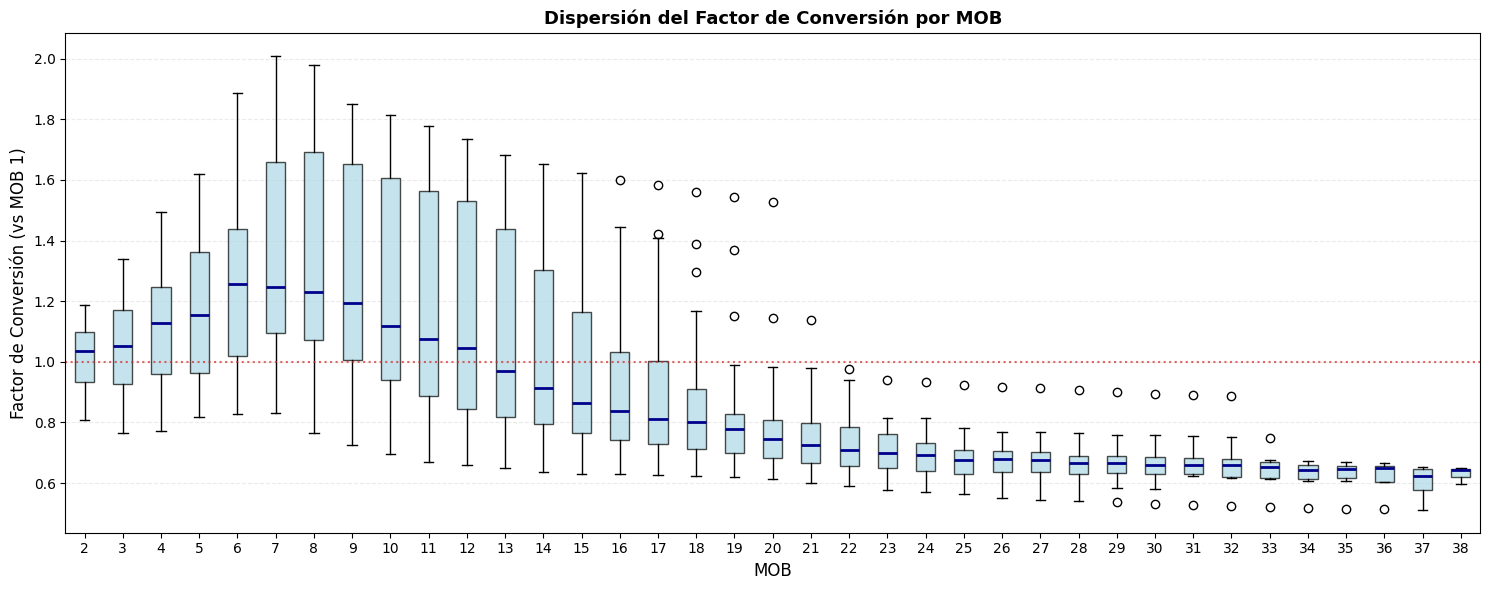

In [9]:
mobs_bp = [m for m in range(2, len(factores_conv.columns) + 1)
           if f"MOB_{m}" in factores_conv.columns and factores_conv[f"MOB_{m}"].dropna().shape[0] >= 3]

data_bp = [factores_conv[f"MOB_{m}"].dropna().values for m in mobs_bp]

fig, ax = plt.subplots(figsize=(15, 6))
bp = ax.boxplot(data_bp, patch_artist=True, labels=[str(m) for m in mobs_bp],
                boxprops=dict(facecolor="lightblue", alpha=0.7),
                medianprops=dict(color="darkblue", linewidth=2))

ax.axhline(y=1.0, color="#d62728", linewidth=1.5, linestyle=":", alpha=0.7)
ax.set_xlabel("MOB", fontsize=12)
ax.set_ylabel("Factor de Conversión (vs MOB 1)", fontsize=12)
ax.set_title("Dispersión del Factor de Conversión por MOB", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.25, linestyle="--", axis="y")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "boxplot_factores_conversion.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Conclusiones automáticas

In [10]:
print("=" * 70)
print("CONCLUSIONES - FACTORES DE CONVERSIÓN")
print("=" * 70)

# Factor al MOB maduro
mob_col = f"MOB_{MOB_MADURO}"
if mob_col in factores_conv.columns:
    vals_maduro = factores_conv[mob_col].dropna()
    prom = vals_maduro.mean()
    print(f"\nFactor promedio MOB 1 → {MOB_MADURO}: {prom:.3f}")
    if prom > 1:
        print(f"  → En promedio, la mora al MOB {MOB_MADURO} es {(prom-1)*100:.1f}% MAYOR que al nacer.")
    else:
        print(f"  → En promedio, la mora al MOB {MOB_MADURO} es {(1-prom)*100:.1f}% MENOR que al nacer.")

# Tendencia
r = resumen[resumen["mob"] == MOB_MADURO]
if not r.empty:
    tend = r.iloc[0]
    print(f"  → Tendencia: {tend['tendencia']} (1ra mitad={tend['prom_1ra_mitad']:.3f}, 2da mitad={tend['prom_2da_mitad']:.3f}, cambio={tend['cambio_pct']:+.1f}%)")

# MOB pico
picos = resumen.loc[resumen["promedio"].idxmax()]
print(f"\nMOB con mayor factor promedio: MOB {int(picos['mob'])} (factor={picos['promedio']:.3f})")
print(f"  → Este es el punto de máximo deterioro relativo respecto al inicio.")

# Correlación MOB1 vs factor maduro
if mob_col in factores_conv.columns:
    mob1 = matriz.loc[vals_maduro.index, "MOB_1"]
    corr = np.corrcoef(mob1, vals_maduro.values)[0, 1]
    print(f"\nCorrelación entre mora inicial (MOB 1) y factor al MOB {MOB_MADURO}: r = {corr:.3f}")
    if abs(corr) > 0.5:
        direccion = "positiva" if corr > 0 else "negativa"
        print(f"  → Relación {direccion} fuerte: {'a mayor mora inicial, mayor deterioro relativo' if corr > 0 else 'a mayor mora inicial, menor deterioro relativo'}.")
    else:
        print(f"  → Relación débil: la mora inicial no predice bien el factor de conversión.")

print("\n" + "=" * 70)

CONCLUSIONES - FACTORES DE CONVERSIÓN

Factor promedio MOB 1 → 15: 0.985
  → En promedio, la mora al MOB 15 es 1.5% MENOR que al nacer.
  → Tendencia: SUBIENDO (1ra mitad=0.827, 2da mitad=1.143, cambio=+38.2%)

MOB con mayor factor promedio: MOB 8 (factor=1.356)
  → Este es el punto de máximo deterioro relativo respecto al inicio.

Correlación entre mora inicial (MOB 1) y factor al MOB 15: r = 0.312
  → Relación débil: la mora inicial no predice bien el factor de conversión.

